# Weather Type Classification & Prediction
A comprehensive machine learning project to analyze, predict, and evaluate weather conditions using atmospheric and environmental features.

## 1. Import Libraries & Load Data
In this section, we import the core data science and visualization libraries, load the dataset, and inspect its basic structure.

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style='whitegrid')


In [2]:
# Load dataset and strip leading/trailing whitespace from column names
df = pd.read_csv('weather_classification_data.csv')
df.columns = df.columns.str.strip()

# Preview first 5 rows
df.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
# Dataset shape and summary info
print('Dataset Shape:', df.shape)
print('-' * 50)
df.info()


Dataset Shape: (13200, 11)
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.6 MB


In [4]:
# Check for missing values
df.isnull().sum()


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [5]:
# Statistical summary of numerical features
df.describe()


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


## 2. Exploratory Data Analysis (EDA)
Analyzing target distributions, feature spreads, outliers, and correlations across meteorological parameters.

### 2.1 Target Variable Distribution (Weather Type)

C:\Users\Daksh Savaliya\AppData\Local\Temp\ipykernel_12320\2433589433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weather Type', palette='Set2')


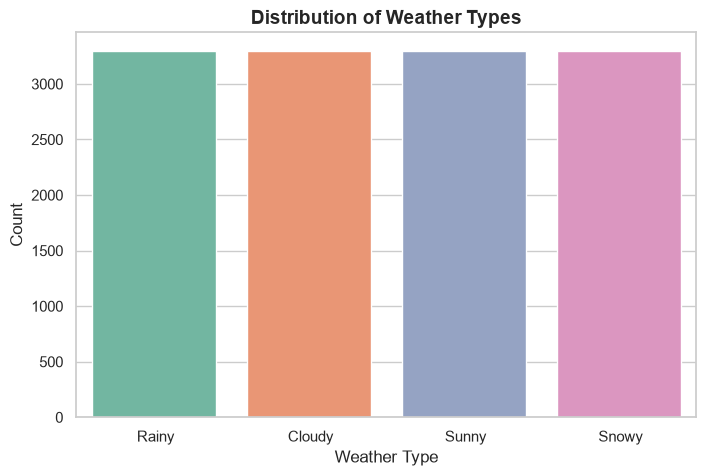

In [6]:
# Distribution of target variable
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Weather Type', palette='Set2')
plt.title('Distribution of Weather Types', fontsize=14, fontweight='bold')
plt.xlabel('Weather Type')
plt.ylabel('Count')
plt.show()


### 2.2 Categorical Features Distribution

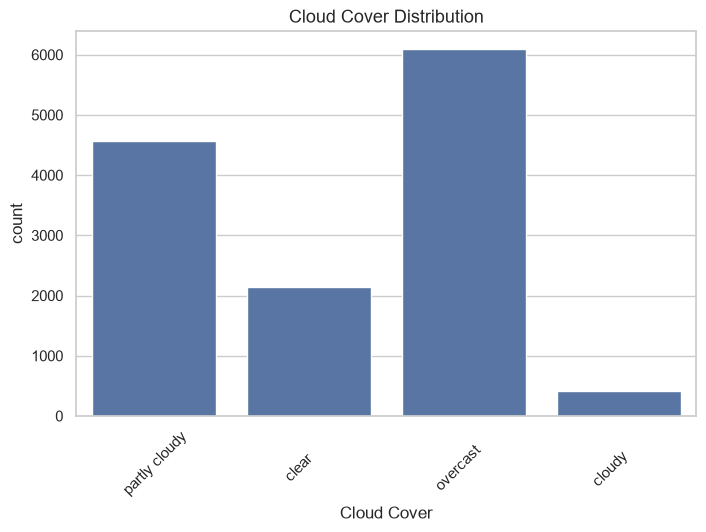

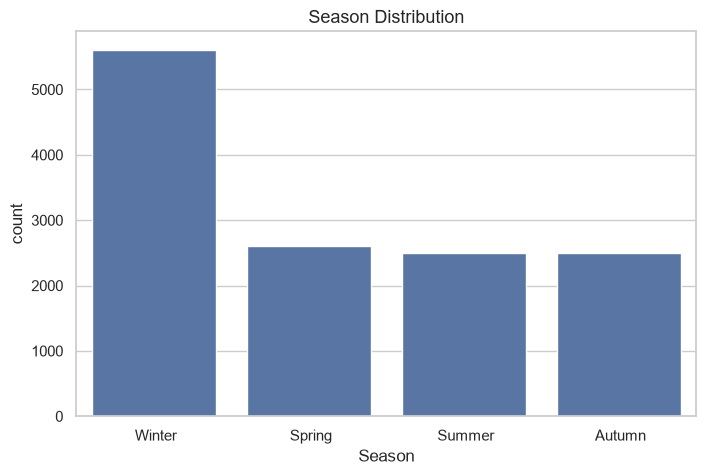

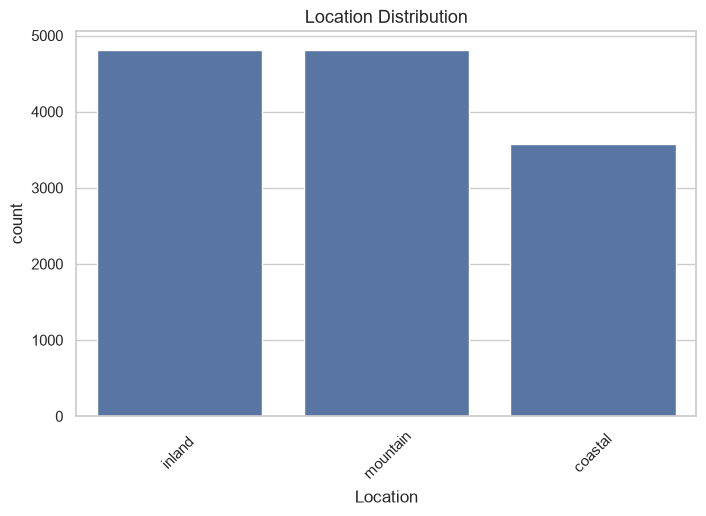

In [7]:
# Cloud Cover distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Cloud Cover')
plt.title('Cloud Cover Distribution', fontsize=13)
plt.xticks(rotation=45)
plt.show()

# Season distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Season')
plt.title('Season Distribution', fontsize=13)
plt.show()

# Location distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Location')
plt.title('Location Distribution', fontsize=13)
plt.xticks(rotation=45)
plt.show()


### 2.3 Numerical Features Distribution & Outliers

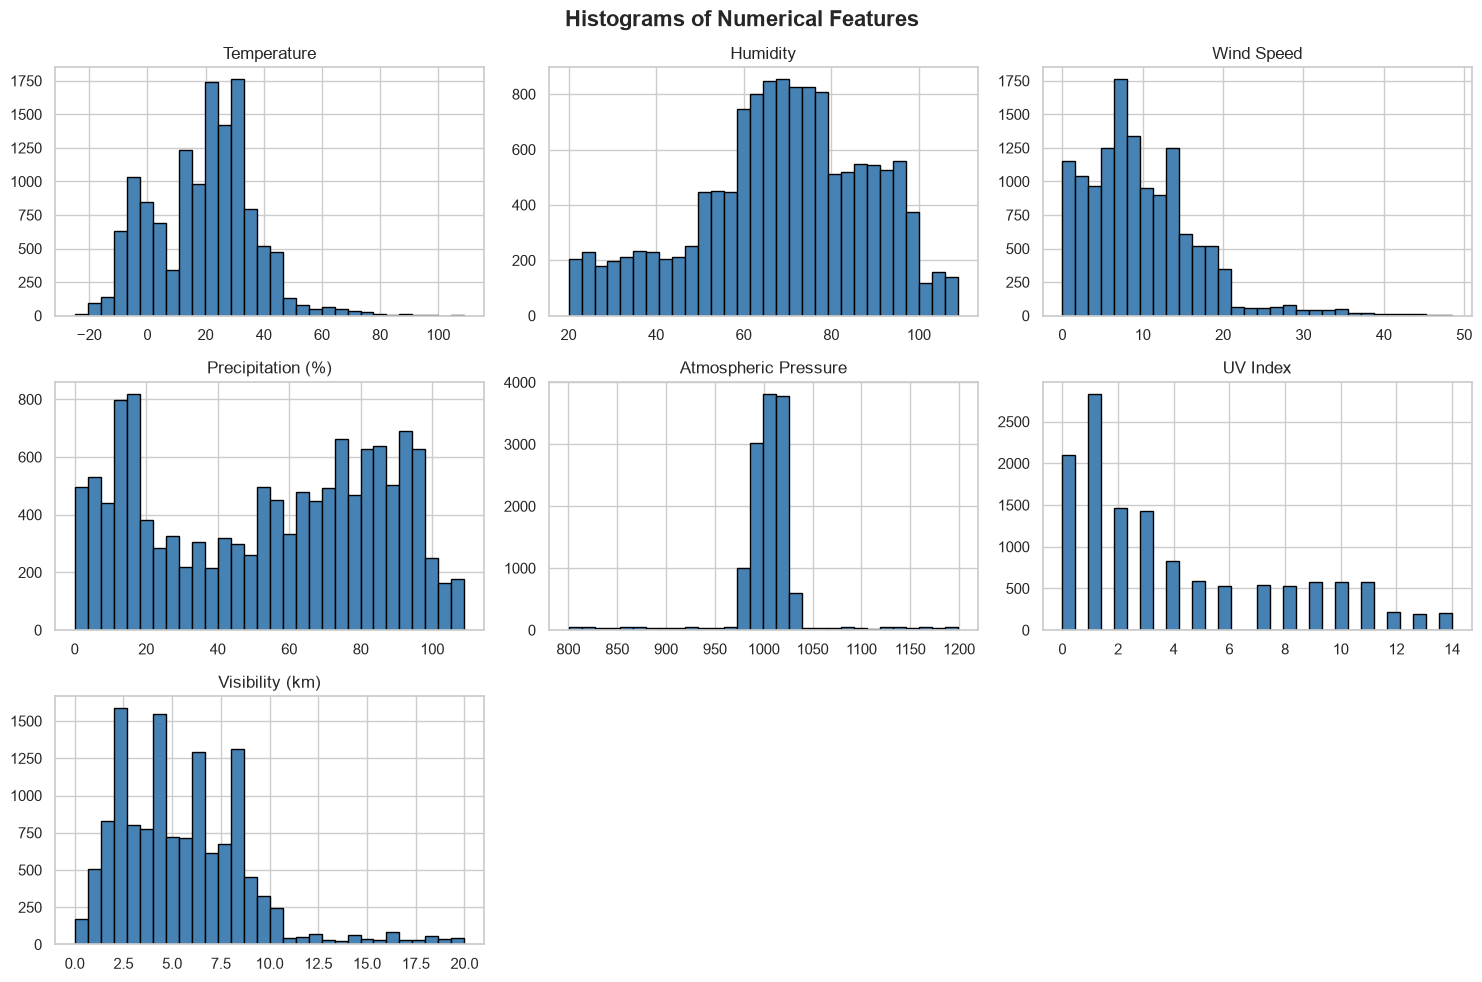

In [8]:
# Histograms for all numerical features
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols].hist(figsize=(15, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


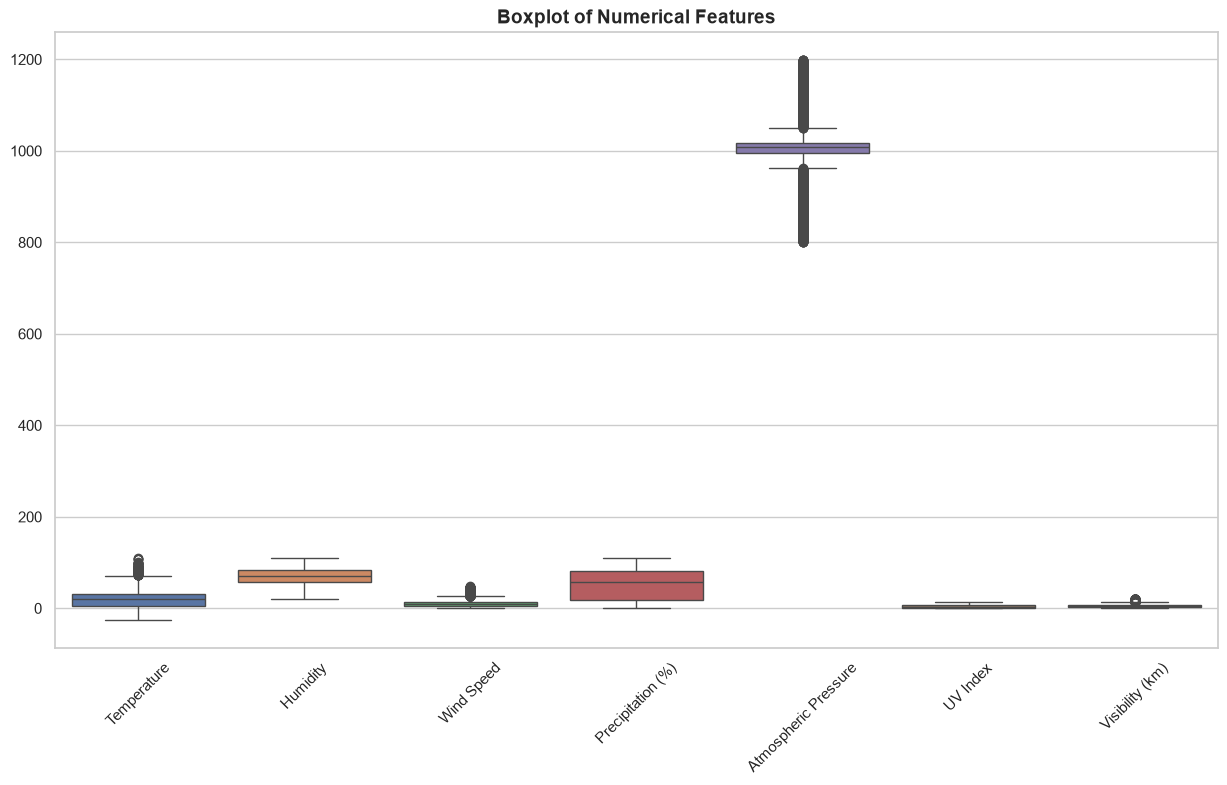

In [9]:
# Boxplots for numerical features to visualize ranges and outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_cols])
plt.title('Boxplot of Numerical Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()


### 2.4 Features vs. Target Variable (Weather Type)
Examining how temperature, humidity, location, and season differ across weather types.

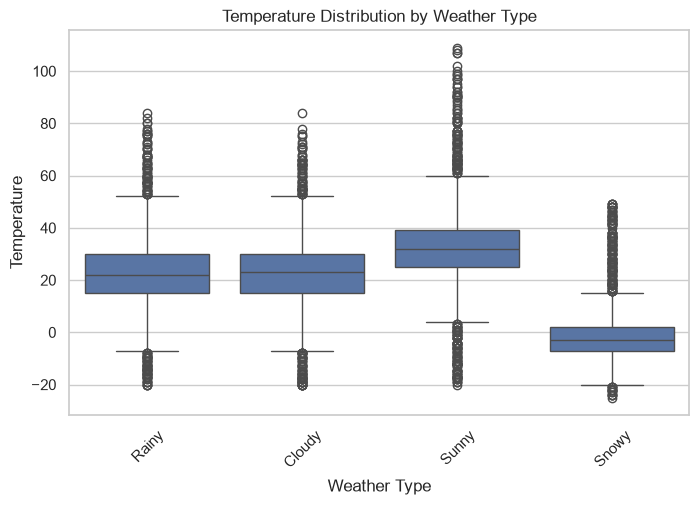

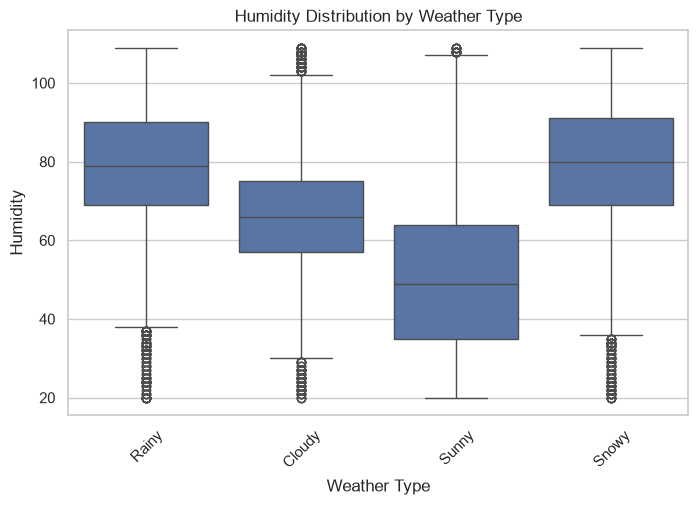

In [10]:
# Temperature by Weather Type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather Type', y='Temperature')
plt.title('Temperature Distribution by Weather Type')
plt.xticks(rotation=45)
plt.show()

# Humidity by Weather Type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather Type', y='Humidity')
plt.title('Humidity Distribution by Weather Type')
plt.xticks(rotation=45)
plt.show()


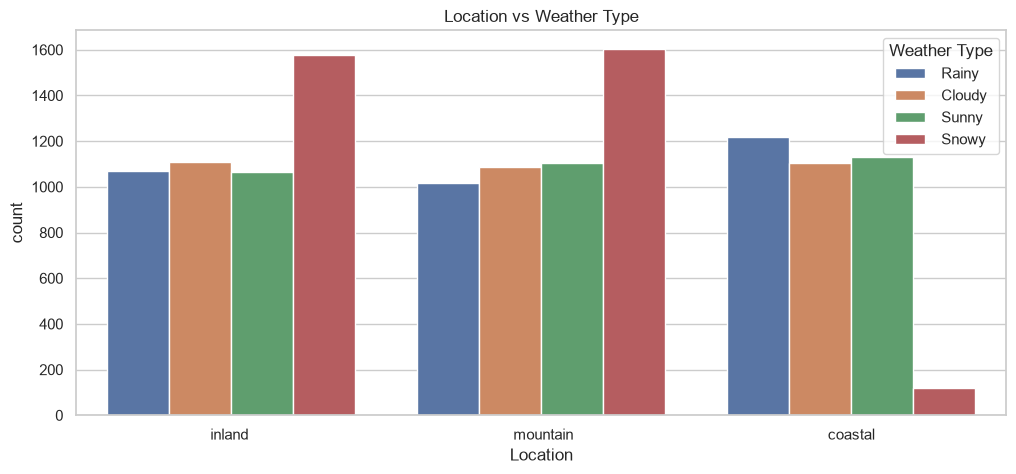

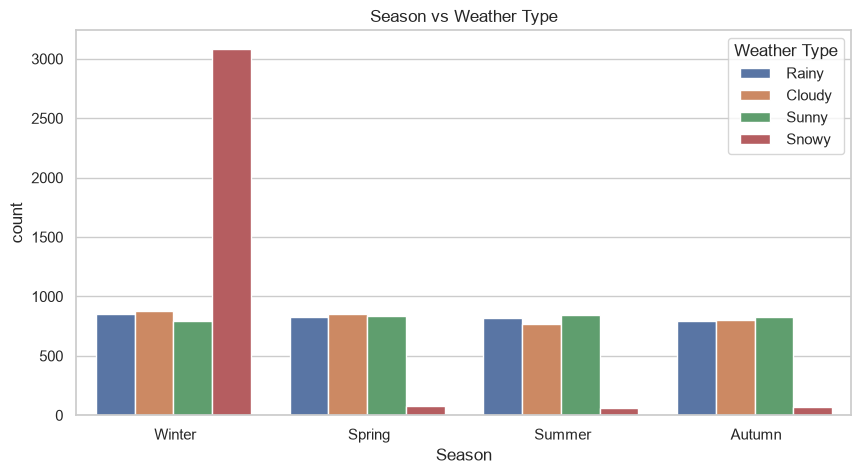

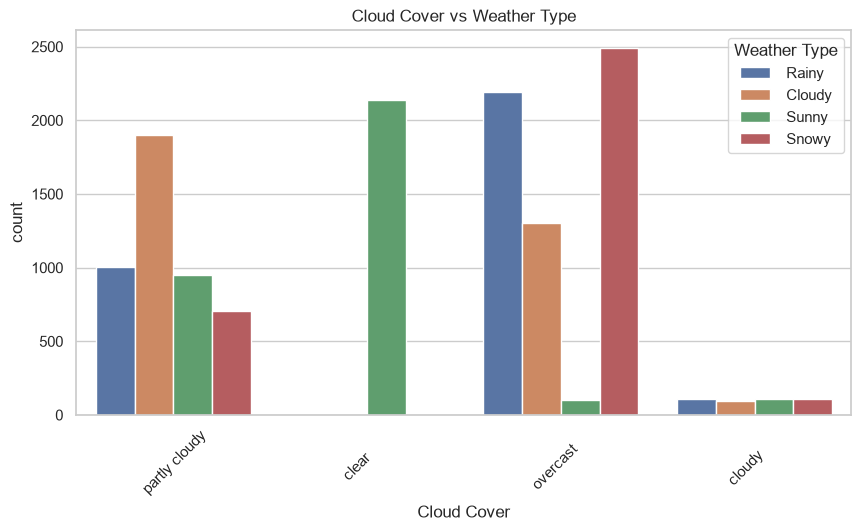

In [11]:
# Location vs Weather Type
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Location', hue='Weather Type')
plt.title('Location vs Weather Type')
plt.show()

# Season vs Weather Type
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Season', hue='Weather Type')
plt.title('Season vs Weather Type')
plt.show()

# Cloud Cover vs Weather Type
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Cloud Cover', hue='Weather Type')
plt.title('Cloud Cover vs Weather Type')
plt.xticks(rotation=45)
plt.show()


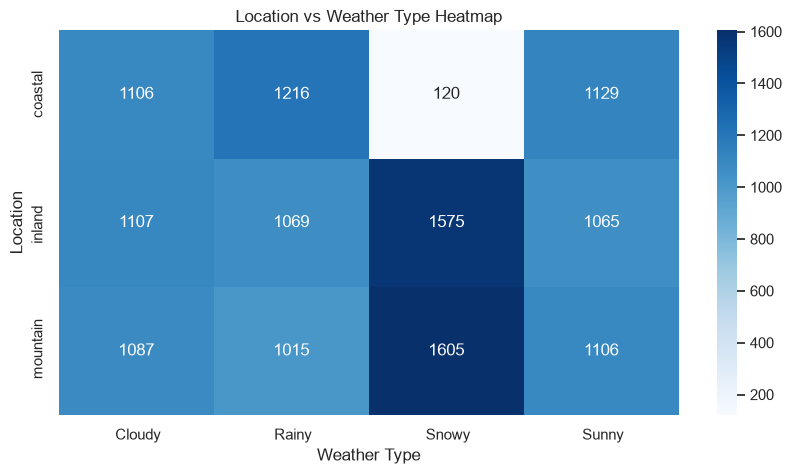

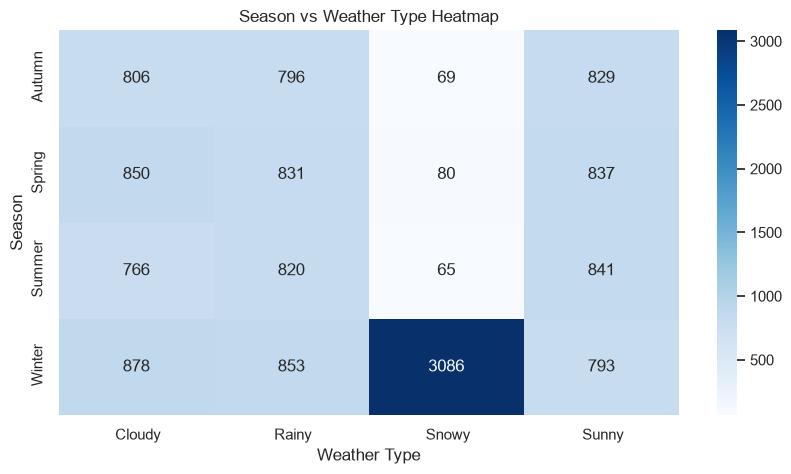

In [12]:
# Heatmaps of cross-tabulated category counts
location_weather = pd.crosstab(df['Location'], df['Weather Type'])
season_weather = pd.crosstab(df['Season'], df['Weather Type'])

plt.figure(figsize=(10, 5))
sns.heatmap(location_weather, annot=True, fmt='d', cmap='Blues')
plt.title('Location vs Weather Type Heatmap')
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(season_weather, annot=True, fmt='d', cmap='Blues')
plt.title('Season vs Weather Type Heatmap')
plt.show()


### 2.5 Correlation & Bivariate Analysis

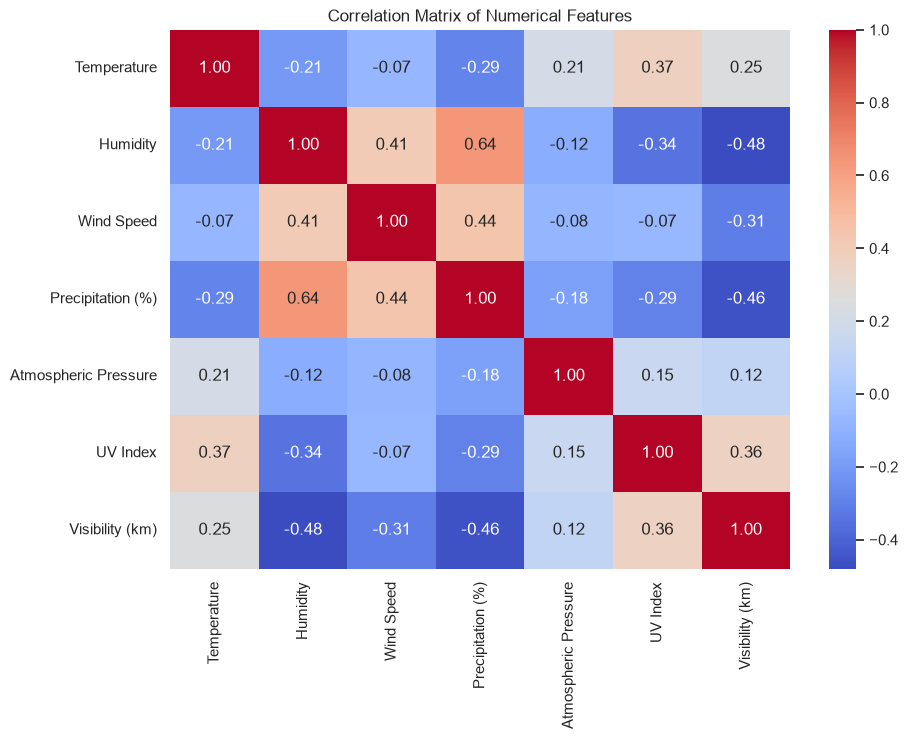

In [13]:
# Correlation Heatmap of numerical features
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


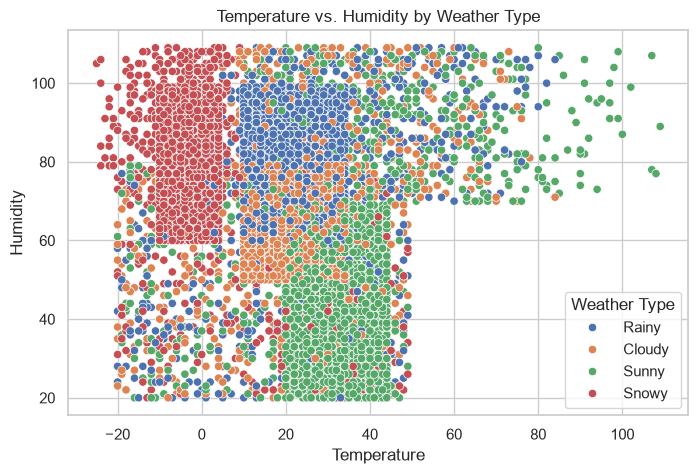

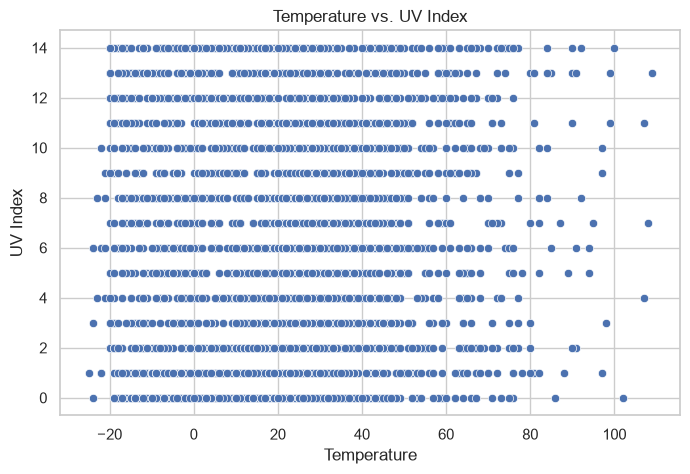

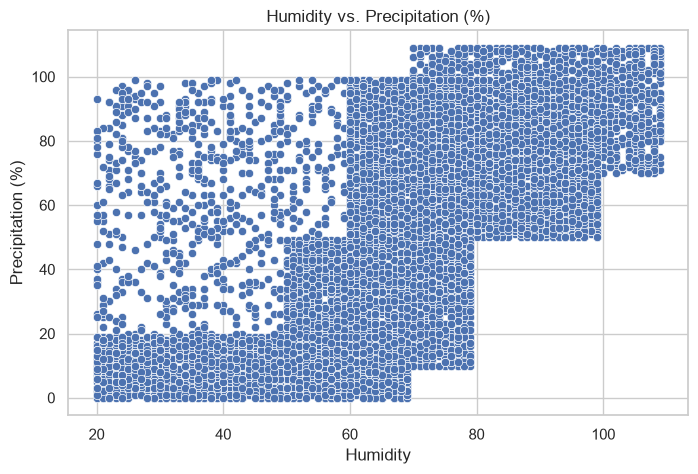

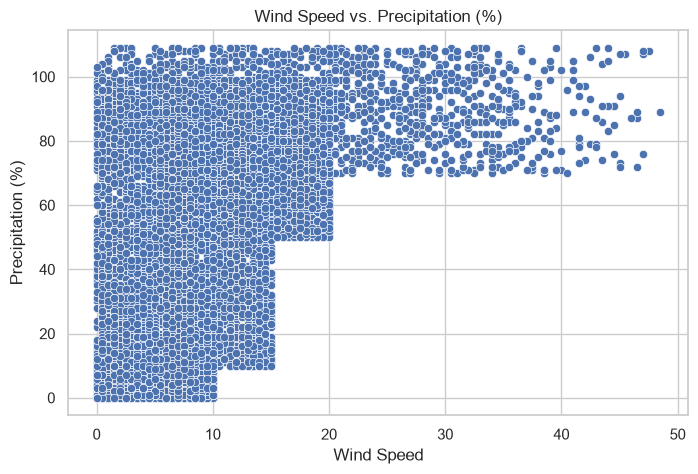

In [14]:
# Scatter plots of key environmental indicators
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Temperature', y='Humidity', hue='Weather Type')
plt.title('Temperature vs. Humidity by Weather Type')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Temperature', y='UV Index')
plt.title('Temperature vs. UV Index')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Humidity', y='Precipitation (%)')
plt.title('Humidity vs. Precipitation (%)')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Wind Speed', y='Precipitation (%)')
plt.title('Wind Speed vs. Precipitation (%)')
plt.show()


## 3. Data Preprocessing & Feature Engineering
Preparing features and target variables:
1. Separate feature matrix X and target vector y.
2. One-Hot Encoding for categorical features (Cloud Cover, Season, Location).
3. Label Encoding for target variable (Weather Type).
4. Train/Test Split (80% train, 20% test with stratify=y).
5. Feature Scaling using StandardScaler for distance-based models.

In [15]:
# Separate features and target
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

# Define column groups
num_cols = [
    'Temperature',
    'Humidity',
    'Wind Speed',
    'Precipitation (%)',
    'Atmospheric Pressure',
    'UV Index',
    'Visibility (km)'
]

cat_cols = [
    'Cloud Cover',
    'Season',
    'Location'
]


In [16]:
# One-Hot Encode categorical features
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(X[cat_cols])
X_cat = pd.DataFrame(X_cat, columns=encoder.get_feature_names_out(cat_cols), index=X.index)

X = X.drop(cat_cols, axis=1)
X = pd.concat([X, X_cat], axis=1)

# Label Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

class_mapping = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))
print('Class Mapping:', class_mapping)
print('Transformed Features Shape:', X.shape)


Class Mapping: {0: ' Cloudy', 1: ' Rainy', 2: ' Snowy', 3: ' Sunny'}
Transformed Features Shape: (13200, 18)


In [17]:
# Train-Test Split (80% training, 20% testing with stratification)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')


Training samples: 10560
Testing samples : 2640


In [18]:
# Standardize features for distance-based models (Logistic Regression, KNN, Naive Bayes)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)


## 4. Model Training & Evaluation
We train and evaluate 5 diverse classification algorithms:
1. **Logistic Regression** (Linear Classifier)
2. **K-Nearest Neighbors (KNN)** (Instance-based Classifier)
3. **Gaussian Naive Bayes** (Probabilistic Classifier)
4. **Decision Tree Classifier** (Tree-based Classifier)
5. **Random Forest Classifier** (Ensemble Model)

Each model is evaluated with Accuracy, Precision, Recall, F1-Score, and a complete per-class **Classification Report**.

In [19]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


### 4.1 Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaler, y_train)
y_pred_log = log_model.predict(X_test_scaler)

print('=== Logistic Regression ===')
print('Accuracy : ', accuracy_score(y_test, y_pred_log))
print('Precision: ', precision_score(y_test, y_pred_log, average='weighted'))
print('Recall   : ', recall_score(y_test, y_pred_log, average='weighted'))
print('F1 Score : ', f1_score(y_test, y_pred_log, average='weighted'))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_log))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_log, target_names=label_encoder.classes_))


=== Logistic Regression ===
Accuracy :  0.8704545454545455
Precision:  0.8712455252831358
Recall   :  0.8704545454545455
F1 Score :  0.8706120684311777

Confusion Matrix:
[[552  68  16  24]
 [ 40 567  45   8]
 [ 27  10 605  18]
 [ 53  21  12 574]]

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.82      0.84      0.83       660
       Rainy       0.85      0.86      0.86       660
       Snowy       0.89      0.92      0.90       660
       Sunny       0.92      0.87      0.89       660

    accuracy                           0.87      2640
   macro avg       0.87      0.87      0.87      2640
weighted avg       0.87      0.87      0.87      2640



### 4.2 K-Nearest Neighbors (KNN)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaler, y_train)
y_pred_knn = knn_model.predict(X_test_scaler)

print('=== K-Nearest Neighbors (k=5) ===')
print('Accuracy : ', accuracy_score(y_test, y_pred_knn))
print('Precision: ', precision_score(y_test, y_pred_knn, average='weighted'))
print('Recall   : ', recall_score(y_test, y_pred_knn, average='weighted'))
print('F1 Score : ', f1_score(y_test, y_pred_knn, average='weighted'))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))


=== K-Nearest Neighbors (k=5) ===
Accuracy :  0.8954545454545455
Precision:  0.8980689712734746
Recall   :  0.8954545454545455
F1 Score :  0.8961270469269838

Confusion Matrix:
[[591  50   7  12]
 [ 45 586  19  10]
 [ 30  14 602  14]
 [ 47  21   7 585]]

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.83      0.90      0.86       660
       Rainy       0.87      0.89      0.88       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.94      0.89      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



### 4.3 Gaussian Naive Bayes

In [22]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaler, y_train)
y_pred_nb = nb_model.predict(X_test_scaler)

print('=== Gaussian Naive Bayes ===')
print('Accuracy : ', accuracy_score(y_test, y_pred_nb))
print('Precision: ', precision_score(y_test, y_pred_nb, average='weighted'))
print('Recall   : ', recall_score(y_test, y_pred_nb, average='weighted'))
print('F1 Score : ', f1_score(y_test, y_pred_nb, average='weighted'))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_nb))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))


=== Gaussian Naive Bayes ===
Accuracy :  0.7863636363636364
Precision:  0.8117021694261228
Recall   :  0.7863636363636364
F1 Score :  0.7877004507144677

Confusion Matrix:
[[530  92  38   0]
 [ 47 512 100   1]
 [ 50  12 598   0]
 [189  30   5 436]]

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.65      0.80      0.72       660
       Rainy       0.79      0.78      0.78       660
       Snowy       0.81      0.91      0.85       660
       Sunny       1.00      0.66      0.79       660

    accuracy                           0.79      2640
   macro avg       0.81      0.79      0.79      2640
weighted avg       0.81      0.79      0.79      2640



### 4.4 Decision Tree Classifier

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print('=== Decision Tree ===')
print('Accuracy : ', accuracy_score(y_test, y_pred_dt))
print('Precision: ', precision_score(y_test, y_pred_dt, average='weighted'))
print('Recall   : ', recall_score(y_test, y_pred_dt, average='weighted'))
print('F1 Score : ', f1_score(y_test, y_pred_dt, average='weighted'))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

# Overfitting Check: Compare Train vs. Test score
print(f'\nTrain Accuracy: {dt_model.score(X_train, y_train):.4f}')
print(f'Test Accuracy : {dt_model.score(X_test, y_test):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))


=== Decision Tree ===
Accuracy :  0.9098484848484848
Precision:  0.910106379696208
Recall   :  0.9098484848484848
F1 Score :  0.9099161859692231

Confusion Matrix:
[[597  32  11  20]
 [ 37 594  15  14]
 [ 15  16 603  26]
 [ 19  20  13 608]]

Train Accuracy: 1.0000
Test Accuracy : 0.9098

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.89      0.90      0.90       660
       Rainy       0.90      0.90      0.90       660
       Snowy       0.94      0.91      0.93       660
       Sunny       0.91      0.92      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



### 4.5 Random Forest Classifier (Ensemble Model)

=== Random Forest ===
Accuracy :  0.9136363636363637
Precision:  0.9147508505557169
Recall   :  0.9136363636363637
F1 Score :  0.9138809023440799

Train Accuracy: 1.0000
Test Accuracy : 0.9136

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.88      0.92      0.90       660
       Rainy       0.89      0.91      0.90       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.94      0.91      0.93       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



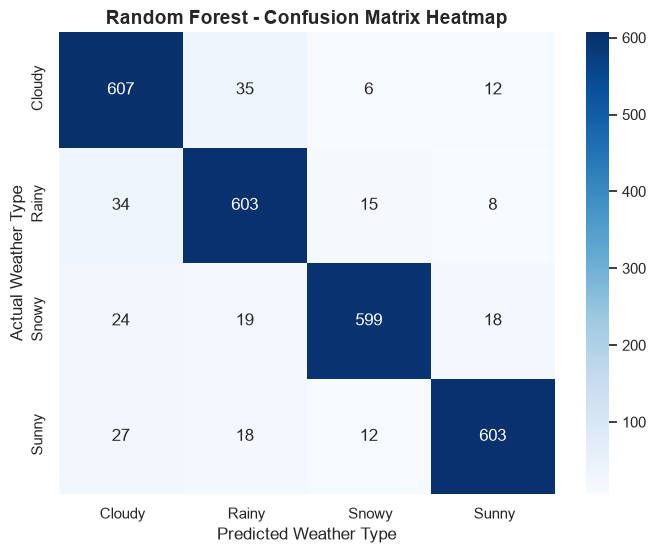

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('=== Random Forest ===')
print('Accuracy : ', accuracy_score(y_test, y_pred_rf))
print('Precision: ', precision_score(y_test, y_pred_rf, average='weighted'))
print('Recall   : ', recall_score(y_test, y_pred_rf, average='weighted'))
print('F1 Score : ', f1_score(y_test, y_pred_rf, average='weighted'))

# Overfitting Check
print(f'\nTrain Accuracy: {rf_model.score(X_train, y_train):.4f}')
print(f'Test Accuracy : {rf_model.score(X_test, y_test):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

# Visual Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest - Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Weather Type')
plt.ylabel('Actual Weather Type')
plt.show()


## 5. Feature Importance Analysis
Analyzing which meteorological parameters have the greatest influence on predicting weather outcomes using the Random Forest model.

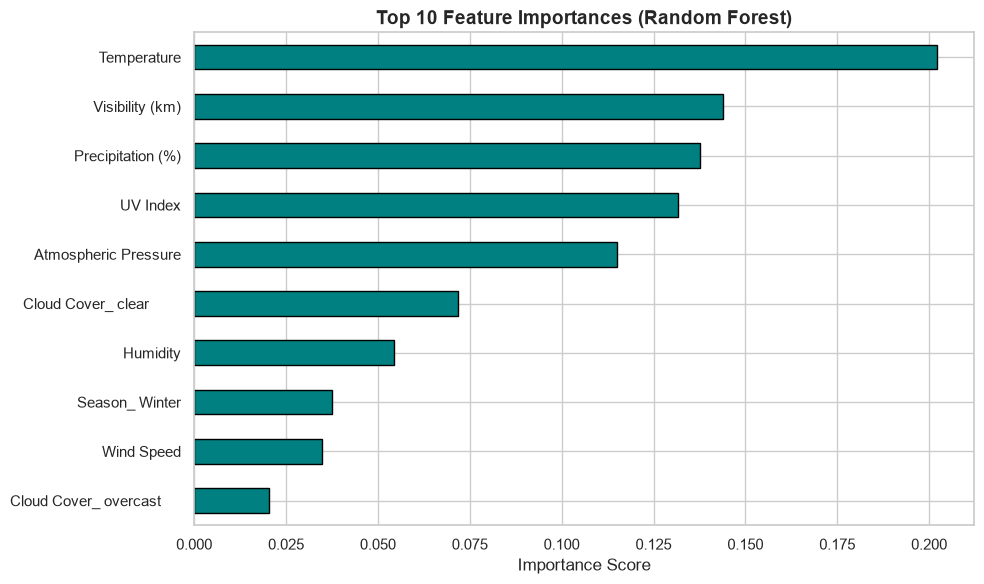

In [25]:
# Feature Importance Bar Chart
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
feat_imp.nlargest(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Model Comparison & Summary
A consolidated comparison of all 5 evaluated algorithms across Accuracy and Weighted F1-Score.

,Model,Accuracy,F1 Score (Weighted)
0,Random Forest,0.913636,0.913881
1,Decision Tree,0.909848,0.909916
2,KNN,0.895455,0.896127
3,Logistic Regression,0.870455,0.870612
4,Naive Bayes,0.786364,0.787700


C:\Users\Daksh Savaliya\AppData\Local\Temp\ipykernel_12320\2076385836.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=models_summary, x='Model', y='Accuracy', palette='viridis')


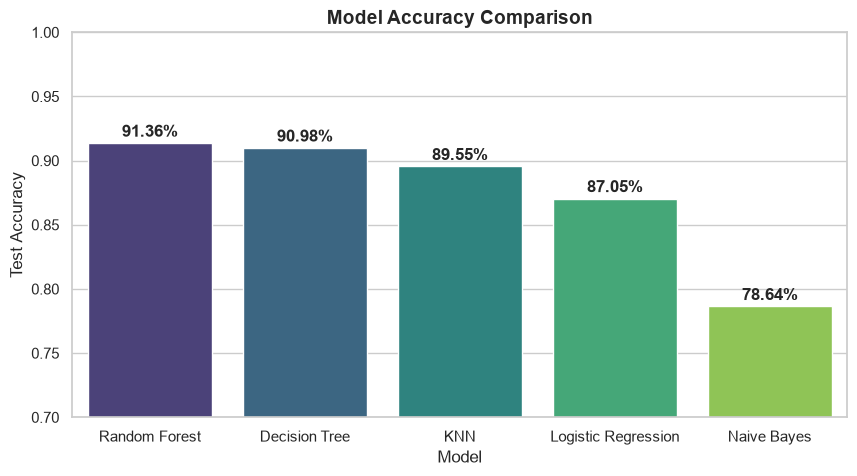

In [26]:
# Comparison DataFrame across all evaluated models
models_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1 Score (Weighted)': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

models_summary = models_summary.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(models_summary)

# Model Performance Comparison Bar Chart
plt.figure(figsize=(10, 5))
barplot = sns.barplot(data=models_summary, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.7, 1.0)
plt.ylabel('Test Accuracy')
for index, row in models_summary.iterrows():
    acc_text = f"{row['Accuracy']:.2%}"
    barplot.text(index, row['Accuracy'] + 0.005, acc_text, ha='center', fontweight='bold')
plt.show()
